# Final Análisis Estadístico de Datos

**Nombre**:  Demo Augusto

**Cuatrimestre**:  Primer cuatrimestre de 2024

Un experimento consiste en contar el número de partículas detectadas por un detector ($k$) sobre un total de partículas incidentes ($n$) para medir la eficiencia del detector. El experimento se repite para distintas energías de la partículas incidentes ($E$). Buscamos ajustar un modelo de la eficiencia $\varepsilon$ en función de la energía en base a los datos medidos. La siguiente tabla muestra los resultados del experimento.  

In [1]:
import numpy as np
import pandas as pd
energy = np.arange(start=0.05, stop=1.05, step=0.05)
ntrials = 30
total_particles = np.full(energy.shape, ntrials)
observed_particles = np.array([0, 0, 0, 3, 3, 2, 8, 5, 4, 11, 18, 15, 19, 20, 26, 24, 26, 29, 30, 30])
data = pd.DataFrame(data = {'Energy': energy, 'Total': total_particles, 'Observed': observed_particles})
data

,Energy,Total,Observed
0,0.05,30,0
1,0.10,30,0
2,0.15,30,0
3,0.20,30,3
4,0.25,30,3
5,0.30,30,2
6,0.35,30,8
7,0.40,30,5
8,0.45,30,4
9,0.50,30,11


In [2]:
# librerias
# por si se ejecuta en colab
#!pip install likefit
import matplotlib.pyplot as plt
import scipy as sp
import likefit

**1**. Calcular el estimador de la eficiencia del detector ($\hat\varepsilon$) para cada energía

Con energía fija, la eficiencia del detector se define como el número de partículas detectadas $k$ sobre el número total de partículas incidentes $n$. Para cada energía será entonces:

$$ \hat{\epsilon} = k/n $$


In [3]:
ef = data['Observed']/data['Total']

**2**. Graficar el estimador de la eficiencia ($\hat\varepsilon$) en función de la energía

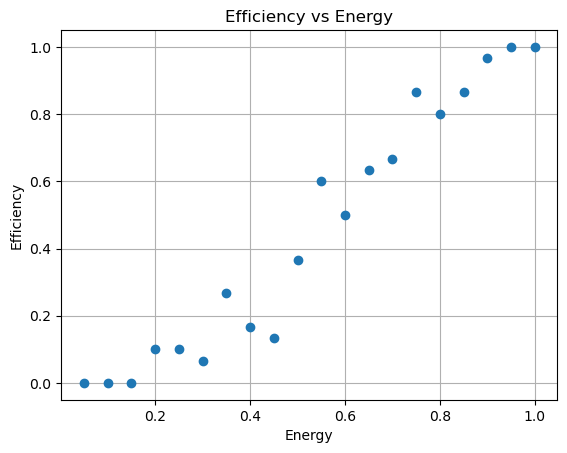

In [4]:
fig, ax1 = plt.subplots()
ax1.plot(data['Energy'], ef, 'o')
ax1.set_xlabel('Energy')
ax1.set_ylabel('Efficiency')
ax1.set_title('Efficiency vs Energy')
ax1.grid(True)
plt.show()

**3**. Escribir el código para el modelo del ajuste  
El modelo de la eficiencia en función de la energía es la función sigmoide,
\begin{equation}
\varepsilon(E;a,b)=\frac{1}{1+\exp(-(E-a)/b)},
\end{equation}
con $a$ y $b$ los parámetros del ajuste.

In [5]:
# definimos una funcion cuyos argumentos sean la energia y un array de los aprametros a y b
def effun(E, param):
    return 1/(1+np.exp(-(E-param[0])/param[1]))

**4**. Ajustar los datos con el modelo de la eficiencia con una función de costo Binomial

Utilizaremos la libreria likefit. Pero antes es buena practica hacer un ajuste inicial para obtener mejores parametros iniciales. Para esto, ajustaremos con scipy y los resultados se los daremos a likefit.

In [6]:
# redefino esta funcion para poder trabajarla con scipy mas comodamente
def effun_2(E, a, b):
    return 1/(1+np.exp(-(E-a)/b))

# ajuste con optimize.curve_fit
init_param, cova = sp.optimize.curve_fit(f=effun_2, xdata= data['Energy'], ydata= ef)

print(f'a inicial = {init_param[0]}')
print(f'b inicial = {init_param[1]}')

a inicial = 0.5746903907236353
b inicial = 0.12700796574828538


In [7]:
# usaremos la libreria likefit
fitter = likefit.Binomial(data['Energy'],data['Total'],data['Observed'],effun)
init_par = [init_param[0], init_param[1]] # uso los parametros iniciales obtenidos con scipy
fit_status = fitter.fit(init_param)

fitter.print_results()

Fit summary
Estimators: [0.57149282 0.12099439]
Errors: [0.01447819 0.00915544]
Covariance matrix: [[2.09617952e-04 4.23282900e-06]
 [4.23282900e-06 8.38219937e-05]]
Correlation matrix: [[1.         0.03193284]
 [0.03193284 1.        ]]
Chi square: 24.010555590050217
Degrees of freedom: 18
Pvalue: 0.15468226740415777


**5**. Reportar los resultados para los parámetros $a$ y $b$ incluyendo los errores correspondientes

In [8]:
estimators = fitter.get_estimators()
errors = fitter.get_errors()

print(f"Parametros (Estimators): {estimators}")
print(f"Errors: {errors}")

Parametros (Estimators): [0.57149282 0.12099439]
Errors: [0.01447819 0.00915544]


**6**. Reportar la correlación entre los estimadores de los parámetros $a$ y $b$

Como sabemos, la correlación esta dada por los elementos que caen fuera de la diagonal de la matriz de covarianza

In [9]:
cov = fitter.get_covariance_matrix()
correlacion = cov[0,1]

print(f'Correlación entre los estimadores de a y b = {correlacion}')

Correlación entre los estimadores de a y b = 4.232828999823272e-06


**7**. Graficar la región de confianza $1\sigma$ de los parámetros $a$ y $b$

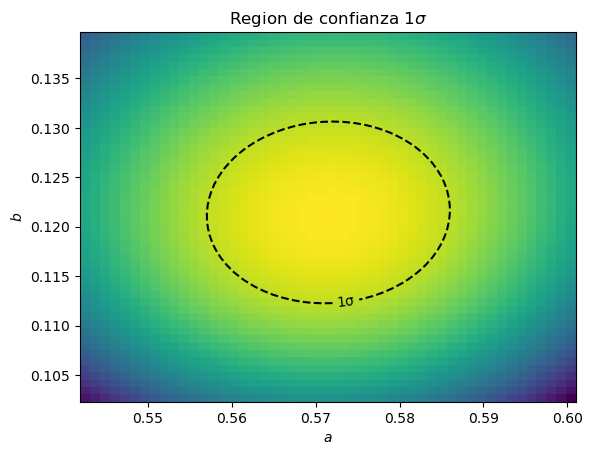

In [10]:
fitter.plot_confidence_regions(parx_index = 0, pary_index = 1, nsigma=1)
plt.xlabel(r'$a$')
plt.ylabel(r'$b$')
plt.title(r'Region de confianza 1$\sigma$')
plt.show()

**8**. Calcular el $\chi^2$ del ajuste y su p-valor. Decidir si el modelo es consistente con los datos.

In [11]:
chi2 = fitter.get_chi_square()
pvalor = fitter.get_pvalue()

print(f'chi2 = {chi2}')
print(f'p-valor = {pvalor}')

chi2 = 24.010555590050217
p-valor = 0.15468226740415777


In [12]:
# grados de libertad del problema
df = len(data['Energy'])-2

# valor critico de chi2 para df=18
import scipy.stats as st
alpha = 0.05
valor_critico = st.chi2.ppf(1-alpha, df)

print(f'grados de libertad = {df}')
print(f'chi2 = {valor_critico}')

grados de libertad = 18
chi2 = 28.869299430392623


Vemos que el p-valor se aleja de los extremos 1 y 0, lo cual indica un buen ajuste.

Podemos decir que el ajuste es bueno ya que el valor crítico de $\chi^2$ para 18 grados de libertad y para un nivel de significancia $\alpha=0.05$ es de $\approx 28,87$, que es mayor que el obtenido con el ajuste realizado, $\approx 24,01$.

Además, que el p-valor resulte mayor que el nivel de significancia también indica que el ajuste es adecuado.

De todas formas, estos dos argumentos no nos permiten descartar la hipótesis nula H0 = "El modelo ajusta los datos".

**9**. Graficar los datos y el ajuste incluyendo la banda de error del ajuste

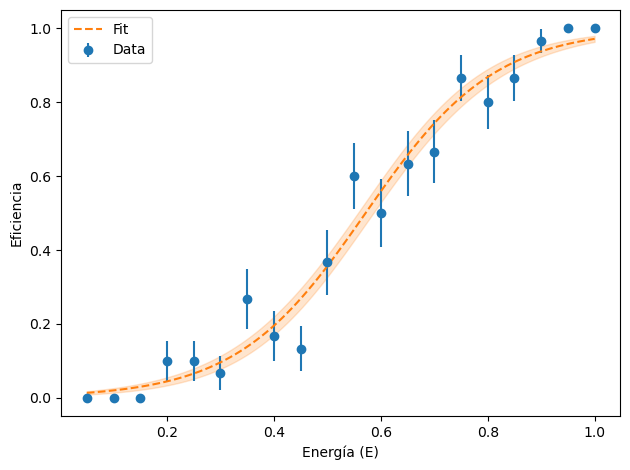

In [13]:
fitter.plot_fit(xlabel="Energía (E)", ylabel="Eficiencia")

Notamos que la banda de error es mas gruesa para las energias del medio.